In [1]:
who_region = {
    "AMERICAN SAMOA": "WPRO",
    "CAMBODIA": "WPRO",
    "COTE D'IVOIRE": "AFRO",
    "GUATEMALA": "AMRO",
    "INDIA": "SEARO",
    "LAO PEOPLE'S DEMOCRATIC REPUBLIC": "WPRO",
    "MAYOTTE": "AFRO",
    "MYANMAR": "SEARO",
    "NORTHERN MARIANA ISLANDS": "WPRO",
    "PALAU": "WPRO",
    "SAINT MARTIN": "AMRO",
    "SENEGAL": "AFRO",
    "ANGOLA": "AFRO",
    "BENIN": "AFRO",
    "BRUNEI DARUSSALAM": "WPRO",
    "GHANA": "AFRO",
    "GUADELOUPE": "AMRO",
    "HONDURAS": "AMRO",
    "INDONESIA": "SEARO",
    "MALAYSIA": "WPRO",
    "MALDIVES": "SEARO",
    "MALI": "AFRO",
    "MAURITIUS": "AFRO",
    "NAURU": "WPRO",
    "NEW CALEDONIA": "WPRO",
    "SAINT VINCENT AND THE GRENADINES": "AMRO",
    "SPAIN": "EURO",
    "TONGA": "WPRO",
    "URUGUAY": "AMRO",
    "ANGUILLA": "AMRO",
    "ANTIGUA AND BARBUDA": "AMRO",
    "BAHAMAS": "AMRO",
    "BELIZE": "AMRO",
    "BERMUDA": "AMRO",
    "CAMEROON": "AFRO",
    "CHINA": "WPRO",
    "ETHIOPIA": "AFRO",
    "GUAM": "WPRO",
    "JAMAICA": "AMRO",
    "KIRIBATI": "WPRO",
    "MEXICO": "AMRO",
    "PUERTO RICO": "AMRO",
    "SAINT KITTS AND NEVIS": "AMRO",
    "SAMOA": "WPRO",
    "TAIWAN": "WPRO",
    "TIMOR-LESTE": "SEARO",
    "TOGO": "AFRO",
    "TUVALU": "WPRO",
    "ARGENTINA": "AMRO",
    "ARUBA": "AMRO",
    "BOLIVIA": "AMRO",
    "BONAIRE, SAINT EUSTATIUS AND SABA": "AMRO",
    "CAYMAN ISLANDS": "AMRO",
    "COSTA RICA": "AMRO",
    "CUBA": "AMRO",
    "GRENADA": "AMRO",
    "HAITI": "AMRO",
    "MARSHALL ISLANDS": "WPRO",
    "MARTINIQUE": "AMRO",
    "MAURITANIA": "AFRO",
    "NIGER": "AFRO",
    "NIUE": "WPRO",
    "OMAN": "EMRO",
    "PAKISTAN": "EMRO",
    "PANAMA": "AMRO",
    "PHILIPPINES": "WPRO",
    "PITCAIRN": "WPRO",
    "SAO TOME AND PRINCIPE": "AFRO",
    "SAUDI ARABIA": "EMRO",
    "SUDAN": "EMRO",
    "THAILAND": "SEARO",
    "TURKS AND CAICOS ISLANDS": "AMRO",
    "VENEZUELA": "AMRO",
    "VIRGIN ISLANDS (UK)": "AMRO",
    "WALLIS AND FUTUNA": "WPRO",
    "BRAZIL": "AMRO",
    "CABO VERDE": "AFRO",
    "CENTRAL AFRICAN REPUBLIC": "AFRO",
    "CHILE": "AMRO",
    "COOK ISLANDS": "WPRO",
    "CURACAO": "AMRO",
    "DOMINICAN REPUBLIC": "AMRO",
    "ECUADOR": "AMRO",
    "ERITREA": "AFRO",
    "FIJI": "WPRO",
    "GUYANA": "AMRO",
    "MONTSERRAT": "AMRO",
    "NEPAL": "SEARO",
    "PARAGUAY": "AMRO",
    "PERU": "AMRO",
    "REUNION": "AFRO",
    "SAINT LUCIA": "AMRO",
    "SEYCHELLES": "AFRO",
    "SINGAPORE": "WPRO",
    "SOLOMON ISLANDS": "WPRO",
    "UNITED REPUBLIC OF TANZANIA": "AFRO",
    "VANUATU": "WPRO",
    "AFGHANISTAN": "EMRO",
    "BHUTAN": "SEARO",
    "CHAD": "AFRO",
    "COLOMBIA": "AMRO",
    "FRANCE": "EURO",
    "FRENCH GUIANA": "AMRO",
    "FRENCH POLYNESIA": "WPRO",
    "HONG KONG": "WPRO",
    "JAPAN": "WPRO",
    "MACAU": "WPRO",
    "MICRONESIA (FEDERATED STATES OF)": "WPRO",
    "NICARAGUA": "AMRO",
    "PAPUA NEW GUINEA": "WPRO",
    "SAINT BARTHELEMY": "AMRO",
    "SURINAME": "AMRO",
    "AUSTRALIA": "WPRO",
    "BANGLADESH": "SEARO",
    "BARBADOS": "AMRO",
    "BURKINA FASO": "AFRO",
    "DOMINICA": "AMRO",
    "EL SALVADOR": "AMRO",
    "GUINEA": "AFRO",
    "ITALY": "EURO",
    "KENYA": "AFRO",
    "SINT MAARTEN": "AMRO",
    "SRI LANKA": "SEARO",
    "TOKELAU": "WPRO",
    "TRINIDAD AND TOBAGO": "AMRO",
    "UNITED STATES OF AMERICA": "AMRO",
    "VIET NAM": "WPRO",
    "VIRGIN ISLANDS (US)": "AMRO",
    "YEMEN": "EMRO"
}

# %%
# Import basic libraries
import pandas as pd
import numpy as np
import seaborn as sns
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point
import os 
from pathlib import Path
import sys
from tqdm import tqdm
import pycwt as wavelet
from pycwt import wct_significance
from pycwt import helpers
import matplotlib.dates as mdates
import scipy
from scipy.signal import detrend
from matplotlib.ticker import LogLocator, FormatStrFormatter

# Read Geoparquet file
gaul_gdf = gpd.read_parquet("/home/patwuch/Documents/projects/Chuang-Lab-TMU/dengue-infection-module/main/external/geoparquet/GAUL_2024_L2.parquet")
ne_admin_0_gdf = gpd.read_parquet("/home/patwuch/Documents/projects/Chuang-Lab-TMU/dengue-infection-module/main/external/geoparquet/ne_10m_admin_0_countries.parquet")
ne_admin_1_gdf = gpd.read_parquet("/home/patwuch/Documents/projects/Chuang-Lab-TMU/dengue-infection-module/main/external/geoparquet/ne_10m_admin_1_states_provinces.parquet")

# Define the mapping
mapping = {
    'gaul0_name': 'adm_0_name',
    'gaul1_name': 'adm_1_name',
    'gaul2_name': 'adm_2_name'
}

# Rename columns
gaul_gdf = gaul_gdf.rename(columns=mapping)

import dask.dataframe as dd

# ---------------------------
# 1️⃣ Load CSV with explicit dtypes
# ---------------------------
dtype_dict = {
    'adm_0_name': 'object',
    'adm_1_name': 'object',
    'adm_2_name': 'object',
    'dengue_total': 'float64'
}

national_ddf = dd.read_csv(
    "/home/patwuch/Documents/projects/Chuang-Lab-TMU/dengue-infection-module/main/raw/global/National_extract_V1_3.csv",
    dtype=dtype_dict
)
spatial_ddf = dd.read_csv(
    "/home/patwuch/Documents/projects/Chuang-Lab-TMU/dengue-infection-module/main/raw/global/Spatial_extract_V1_3.csv",
    dtype=dtype_dict
)

temporal_ddf = dd.read_csv(
    "/home/patwuch/Documents/projects/Chuang-Lab-TMU/dengue-infection-module/main/raw/global/Temporal_extract_V1_3.csv",
    dtype=dtype_dict
)


In [14]:
gaul_gdf.sample(20)
asia_gaul_gdf = gaul_gdf[gaul_gdf['continent']=='Asia']

In [18]:
asia_gaul_gdf

,iso3_code,map_code,gaul0_code,adm_0_name,gaul1_code,adm_1_name,gaul2_code,adm_2_name,continent,disp_en,geometry
14038,xAC,xAC,224,AKSAI CHIN,2432,ADMINISTRATIVE UNIT NOT AVAILABLE,124094,Administrative Unit Not Available,Asia,Aksai Chin,"POLYGON ((79.34762 35.98677, 79.35047 35.98611..."
14039,ARM,ARM,225,ARMENIA,2433,ARAGATSOTN,124095,Aparan,Asia,"Aparan, Aragatsotn, Armenia","POLYGON ((44.44758 40.6034, 44.48024 40.59413,..."
14040,ARM,ARM,225,ARMENIA,2433,ARAGATSOTN,124096,Aragats,Asia,"Aragats, Aragatsotn, Armenia","POLYGON ((44.16873 40.60675, 44.1029 40.61021,..."
14041,ARM,ARM,225,ARMENIA,2433,ARAGATSOTN,124097,Ashtarak,Asia,"Ashtarak, Aragatsotn, Armenia","POLYGON ((44.25511 40.43641, 44.2795 40.43243,..."
14042,ARM,ARM,225,ARMENIA,2433,ARAGATSOTN,124098,Talin,Asia,"Talin, Aragatsotn, Armenia","POLYGON ((43.78466 40.5164, 43.81952 40.50066,..."
...,...,...,...,...,...,...,...,...,...,...,...
45407,YEM,YEM,282,YEMEN,3289,TA'IZ,133962,Sabir Al Mawadim,Asia,"Sabir Al Mawadim, Ta'Iz, Yemen","MULTIPOLYGON (((44.12191 13.5861, 44.12513 13...."
45408,YEM,YEM,282,YEMEN,3289,TA'IZ,133963,Salh,Asia,"Salh, Ta'Iz, Yemen","POLYGON ((44.023 13.60197, 44.0335 13.60283, 4..."
45409,YEM,YEM,282,YEMEN,3289,TA'IZ,133964,Sama,Asia,"Sama, Ta'Iz, Yemen","POLYGON ((44.10847 13.35604, 44.09671 13.36626..."
45410,YEM,YEM,282,YEMEN,3289,TA'IZ,133965,Shara'B Ar Rawnah,Asia,"Shara'B Ar Rawnah, Ta'Iz, Yemen","POLYGON ((43.78588 13.84948, 43.78818 13.84844..."


In [ ]:
# Basic plot
asia_gaul_gdf.explore( # color by a specific column
    cmap="Set1",        # colormap
    tooltip="adm_0_name"      # show name on hover
)

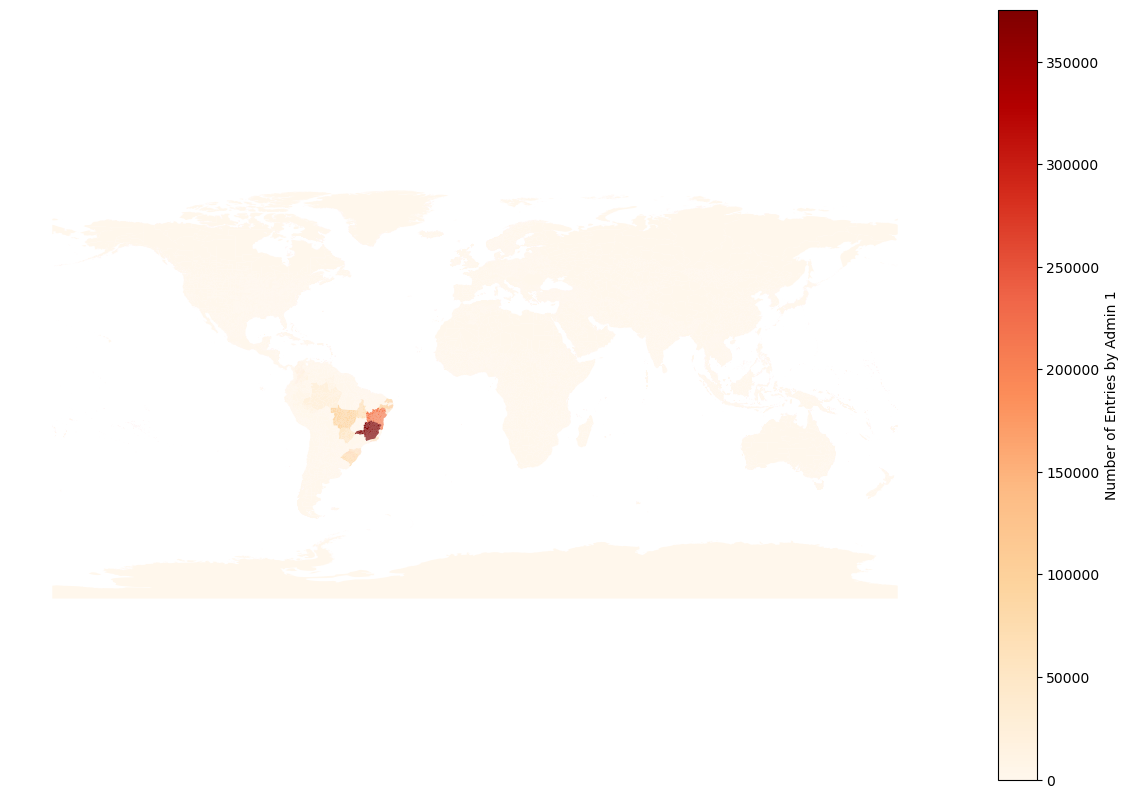

In [ ]:
import dask.dataframe as dd
import geopandas as gpd

def clean_names(df, col):
    return df[col].astype(str).str.upper().str.strip()



# 1. Aggregate: Count entries per adm_1_name
# We also include 'adm_0_name' to ensure uniqueness (preventing "Springfield" overlaps)
counts_ddf = temporal_ddf.groupby(['adm_0_name', 'adm_1_name']).size().to_frame('entry_count')

# 2. Compute: Bring the small aggregated result into memory as a Pandas DataFrame
counts_df = counts_ddf.compute().reset_index()

# Clean Dask/Pandas DF
counts_df['adm_0_name'] = clean_names(counts_df, 'adm_0_name')
counts_df['adm_1_name'] = clean_names(counts_df, 'adm_1_name')

# Clean GeoDataFrame
gaul_gdf['adm_0_name'] = clean_names(gaul_gdf, 'adm_0_name')
gaul_gdf['adm_1_name'] = clean_names(gaul_gdf, 'adm_1_name')

# Merge the counts onto the spatial geometries
merged_gdf = gaul_gdf.merge(counts_df, on=['adm_0_name', 'adm_1_name'], how='left')

# Fill NaN with 0 for areas with no entries
merged_gdf['entry_count'] = merged_gdf['entry_count'].fillna(0)

# Plot the Choropleth
ax = merged_gdf.plot(
    column='entry_count', 
    cmap='OrRd', 
    legend=True, 
    figsize=(15, 10),
    legend_kwds={'label': "Number of Entries by Admin 1"}
)
ax.set_axis_off()

In [ ]:
import dask.dataframe as dd
import pandas as pd

def score_resolution_ordered(df, target_regions):
    # 1. Map Region and Filter
    df = df.assign(region=df['adm_0_name'].map(who_region))
    df = df[df['region'].isin(target_regions)]
    
    # 2. Temporal: Label (Categorical) and Score (Integer)
    t_order = ['Week', 'Month', 'Year']
    t_map = {'Week': 1, 'Month': 2, 'Year': 3}
    
    # We create the score first as an int, then set the label as category
    df = df.assign(t_score=df['T_res'].map(t_map).fillna(3).astype(int))
    df['T_res'] = df['T_res'].astype(pd.CategoricalDtype(categories=t_order, ordered=True))
    
    # 3. Spatial: Label (Categorical) and Score (Integer)
    # Initialize both
    df = df.assign(s_res_label='adm_0', s_score=3)
    df['s_score'] = df['s_score'].astype(int) 
    
    # Use .mask to update both the string label and the integer score
    mask_adm1 = df['adm_1_name'].notnull()
    df['s_res_label'] = df['s_res_label'].mask(mask_adm1, 'adm_1')
    df['s_score'] = df['s_score'].mask(mask_adm1, 2)
    
    mask_adm2 = df['adm_2_name'].notnull()
    df['s_res_label'] = df['s_res_label'].mask(mask_adm2, 'adm_2')
    df['s_score'] = df['s_score'].mask(mask_adm2, 1)
    
    # Finalize the categorical type for the spatial label
    s_order = ['adm_2', 'adm_1', 'adm_0']
    df['s_res_label'] = df['s_res_label'].astype(pd.CategoricalDtype(categories=s_order, ordered=True))
    
    # 4. Composite Score (Now safe because both are integers)
    df = df.assign(total_res_score = df['t_score'] + df['s_score'])
    
    return df

# Apply
T_ordered = score_resolution_ordered(temporal_ddf, ['WPRO', 'SEARO'])
S_ordered = score_resolution_ordered(spatial_ddf, ['WPRO', 'SEARO'])

In [ ]:
T_ordered.columns

In [ ]:
S_ordered['adm_1_name'].unique().compute()

In [ ]:
len(spatial_ddf), len(temporal_ddf), len(national_ddf)

In [ ]:
import dask.dataframe as dd
import pandas as pd

def score_resolution_ordered(df, target_regions):
    # 1. Map Region and Filter
    df = df.assign(region=df['adm_0_name'].map(who_region))
    df = df[df['region'].isin(target_regions)]
    
    # 2. Temporal: Label (Categorical) and Score (Integer)
    t_order = ['Week', 'Month', 'Year']
    t_map = {'Week': 1, 'Month': 2, 'Year': 3}
    
    # We create the score first as an int, then set the label as category
    df = df.assign(t_score=df['T_res'].map(t_map).fillna(3).astype(int))
    df['T_res'] = df['T_res'].astype(pd.CategoricalDtype(categories=t_order, ordered=True))
    
    # 3. Spatial: Label (Categorical) and Score (Integer)
    # Initialize both
    df = df.assign(s_res_label='adm_0', s_score=3)
    df['s_score'] = df['s_score'].astype(int) 
    
    # Use .mask to update both the string label and the integer score
    mask_adm1 = df['adm_1_name'].notnull()
    df['s_res_label'] = df['s_res_label'].mask(mask_adm1, 'adm_1')
    df['s_score'] = df['s_score'].mask(mask_adm1, 2)
    
    mask_adm2 = df['adm_2_name'].notnull()
    df['s_res_label'] = df['s_res_label'].mask(mask_adm2, 'adm_2')
    df['s_score'] = df['s_score'].mask(mask_adm2, 1)
    
    # Finalize the categorical type for the spatial label
    s_order = ['adm_2', 'adm_1', 'adm_0']
    df['s_res_label'] = df['s_res_label'].astype(pd.CategoricalDtype(categories=s_order, ordered=True))
    
    # 4. Composite Score (Now safe because both are integers)
    df = df.assign(total_res_score = df['t_score'] + df['s_score'])
    
    return df

# Apply
T_ordered = score_resolution_ordered(temporal_ddf, ['WPRO', 'SEARO', 'EMRO'])
S_ordered = score_resolution_ordered(spatial_ddf, ['WPRO', 'SEARO', 'EMRO'])

In [ ]:
import pandas as pd

# 1. Get total entry counts (rows)
counts = T_ordered.groupby(['T_res', 's_res_label']).size().compute().rename('entry_count')

# 2. Get the unique combinations of resolutions and administrative names
# This is much smaller than the full DDF, making the following steps fast
unique_geo = (
    T_ordered[['T_res', 's_res_label', 'adm_0_name', 'adm_1_name', 'adm_2_name']]
    .drop_duplicates()
    .compute()
)

# 3. Aggregate unique counts and list countries from the unique_geo dataframe
geo_summary = unique_geo.groupby(['T_res', 's_res_label']).agg({
    'adm_0_name': [('country_count', 'nunique'), ('countries', lambda x: list(x.unique()))],
    'adm_1_name': [('adm1_unique_count', 'nunique')],
    'adm_2_name': [('adm2_unique_count', 'nunique')]
})

# 4. Clean up MultiIndex columns
geo_summary.columns = [col[1] for col in geo_summary.columns]

# 5. Join with the total entry counts
final_summary = pd.concat([counts, geo_summary], axis=1).reset_index()

# 6. Sort and Display
final_summary = final_summary.sort_values(['T_res', 's_res_label'])
print(final_summary)

In [ ]:
final_summary

In [ ]:
# 1. Get only the combos that actually showed entries in your summary
active_combos = summary[summary['entry_count'] > 0][['T_res', 's_res_label']].values

for t_res, s_label in active_combos:
    # 2. Force the filter to evaluate as strings to avoid Categorical mismatch
    # We use .loc to be explicit
    mask = (T_ordered['T_res'].astype(str) == str(t_res)) & \
           (T_ordered['s_res_label'].astype(str) == str(s_label))
    
    # 3. Pull the sample
    sample = T_ordered.loc[mask].head(3, npartitions=-1) # Search all partitions
    
    print(f"\nGroup: {t_res} | {s_label} (Expected {summary.loc[(summary['T_res']==t_res) & (summary['s_res_label']==s_label), 'entry_count'].values[0]} rows)")
    
    if len(sample) > 0:
        print(sample[['adm_0_name', 'adm_1_name', 'adm_2_name', 'T_res', 's_res_label']])
    else:
        print("!!! Still empty - This implies a Dask Index/Partition mismatch.")

In [ ]:
# This will now be sorted: Week -> Month -> Year and adm_2 -> adm_1 -> adm_0
T_balance_matrix = T_ordered.groupby(['T_res', 's_res_label']).size().compute().unstack()

# Fill NaNs with 0 to make the "data deserts" obvious
print(T_balance_matrix.fillna(0).astype(int))

# This will now be sorted: Week -> Month -> Year and adm_2 -> adm_1 -> adm_0
S_balance_matrix = S_ordered.groupby(['T_res', 's_res_label']).size().compute().unstack()

# Fill NaNs with 0 to make the "data deserts" obvious
print(S_balance_matrix.fillna(0).astype(int))

In [ ]:
# Check how many countries support each resolution level
coverage = T_ordered.groupby(['T_res', 's_res_label'])['adm_0_name'].nunique().compute().unstack()
print(coverage)

In [ ]:
import dask.dataframe as dd

# 1. Map the 'region' column using .assign
# This ensures 'region' is part of the graph for all subsequent steps
temporal_ddf = temporal_ddf.assign(region=temporal_ddf['adm_0_name'].map(who_region))

# 2. Filter valid mappings
# Instead of creating a separate mask object, do it inline to maintain alignment
T_mapped_ddf = temporal_ddf[temporal_ddf['region'].notnull()]

# 3. Filter for target regions
target_regions = ['WPRO', 'SEARO', 'EMRO']
# Use the .isin() directly on the dataframe we are filtering
T_asia_ddf = T_mapped_ddf[T_mapped_ddf['region'].isin(target_regions)]

# 4. Final temporal filter
T_asia_week_ddf = T_asia_ddf[T_asia_ddf['T_res'] == 'Week']

# 5. Handle failed mappings separately if needed
T_dropped_ddf = T_mapped_ddf[T_mapped_ddf['region'].isna()]


# 1. Map the 'region' column using .assign
# This ensures 'region' is part of the graph for all subsequent steps
spatial_ddf = spatial_ddf.assign(region=spatial_ddf['adm_0_name'].map(who_region))

# 2. Filter valid mappings
# Instead of creating a separate mask object, do it inline to maintain alignment
S_mapped_ddf = spatial_ddf[spatial_ddf['region'].notnull()]

# 3. Filter for target regions
target_regions = ['WPRO', 'SEARO', 'EMRO']
# Use the .isin() directly on the dataframe we are filtering
S_asia_ddf = S_mapped_ddf[S_mapped_ddf['region'].isin(target_regions)]

# 4. Final temporal filter
S_asia_week_ddf = S_asia_ddf[S_asia_ddf['T_res'] == 'Week']

# 5. Handle failed mappings separately if needed
S_dropped_ddf = S_mapped_ddf[S_mapped_ddf['region'].isna()]

In [ ]:
# Calculate counts on the lazy dask series, then compute to get the result
temporal_counts = temporal_ddf['region'].value_counts().compute()
print("Temporal Region Counts:")
print(temporal_counts)

# To see T_res counts specifically
t_res_counts = temporal_ddf['T_res'].value_counts().compute()
print("\nTemporal T_res Counts:")
print(t_res_counts)

# To see S_res counts specifically
s_res_counts = temporal_ddf['S_res'].value_counts().compute()
print("\nSpatial S_res Counts:")
print(s_res_counts)

In [ ]:
# Group by all three dimensions
triple_counts = spatial_ddf.groupby(['T_res', 'S_res', 'region']).size().compute()

# Identify the unique labels for our X and Y axes
t_resolutions = triple_counts.index.get_level_values('T_res').unique()
s_resolutions = triple_counts.index.get_level_values('S_res').unique()

import matplotlib.pyplot as plt
import numpy as np

# 1. Get unique regions and assign a permanent color to each
unique_regions = triple_counts.index.get_level_values('region').unique()
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_regions)))
color_map = dict(zip(unique_regions, colors))

# 2. Setup the grid
t_res_list = triple_counts.index.get_level_values('T_res').unique()
s_res_list = triple_counts.index.get_level_values('S_res').unique()

fig, axes = plt.subplots(len(t_res_list), len(s_res_list), 
                         figsize=(5 * len(s_res_list), 5 * len(t_res_list)))

# Ensure axes is a 2D array even for 1x1 or 1xN grids
axes = np.atleast_2d(axes)

# Function to display raw count instead of percentage
def label_format(pct, all_vals):
    absolute = int(np.round(pct/100.*np.sum(all_vals)))
    return f"{absolute}"

for i, t_val in enumerate(t_res_list):
    for j, s_val in enumerate(s_res_list):
        ax = axes[i, j]
        
        try:
            # Extract data for this cell
            block_data = triple_counts.xs((t_val, s_val), level=('T_res', 'S_res'))
            
            if not block_data.empty:
                # Use the global color map to ensure consistency
                block_colors = [color_map[reg] for reg in block_data.index]
                
                # Plot pie with absolute counts
                ax.pie(block_data, 
                       labels=block_data.index, 
                       autopct=lambda pct: label_format(pct, block_data),
                       colors=block_colors,
                       startangle=140)
                
                total_in_block = block_data.sum()
                ax.set_xlabel(f"Total: {total_in_block}", fontsize=10)
            else:
                ax.text(0.5, 0.5, 'No Data', ha='center')
        except KeyError:
            ax.text(0.5, 0.5, 'No Data', ha='center')

        # Axis labeling
        if i == 0: ax.set_title(f"S_res: {s_val}\n", fontweight='bold')
        if j == 0: ax.set_ylabel(f"T_res: {t_val}", fontweight='bold', labelpad=50, rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
spatial_counts = spatial_ddf['region'].value_counts().compute()
print("Spatial Region Counts:")
print(spatial_counts)

# To see S_res counts specifically
s_res_counts = spatial_ddf['S_res'].value_counts().compute()
print("\nSpatial S_res Counts:")
print(s_res_counts)

In [ ]:
len(S_mapped_ddf), len(S_asia_ddf), len(S_asia_week_ddf), len(S_dropped_ddf)

In [ ]:
def join_flexible_grained(ddf, gdf):
    # Standardize Join Keys
    keys = ['adm_0_name', 'adm_1_name', 'adm_2_name']
    
    for k in keys:
        if k in ddf.columns:
            ddf[k] = ddf[k].fillna('none').astype(str).str.lower().str.strip()
        if k in gdf.columns:
            gdf[k] = gdf[k].fillna('none').astype(str).str.lower().str.strip()

    # Inner join - ensure gdf is a standard GeoDataFrame here for the right side
    joined = ddf.merge(gdf[keys + ['geometry']], on=keys, how='inner')
    return joined

# --- EXECUTION ---

# 1. Join
merged_ddf = join_flexible_grained(spatial_ddf, gaul_gdf)

# 2. Precise Mapping
# Pre-process the dict outside the Dask graph
who_map_clean = {str(k).lower().strip(): str(v).upper().strip() for k, v in who_region.items()}

# 3. Map and Filter in one go to save overhead
merged_ddf['region'] = merged_ddf['adm_0_name'].map(who_map_clean, meta=('region', 'string'))

target_regions = ['WPRO', 'SEARO', 'EMRO']
filtered_ddf = merged_ddf[merged_ddf['region'].isin(target_regions)]

# 4. Cast to GeoPandas LAST
# This ensures all heavy filtering is done before the expensive spatial conversion
final_spatial = dask_geopandas.from_dask_dataframe(filtered_ddf)
final_spatial = final_spatial.set_geometry('geometry')
final_spatial.crs = "EPSG:4326"

# DIAGNOSTIC: If this is 0, your 'adm_0_name' values don't match your dictionary keys.
print("Sample of adm_0_name:", merged_ddf['adm_0_name'].head(5))
print("Sample of map keys:", list(who_map_clean.keys())[:5])

In [ ]:
merged_ddf[merged_ddf['region']=='WPRO'].head()

In [ ]:
# %%
# Import basic libraries
import pandas as pd
import numpy as np
import seaborn as sns
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point
import os 
from pathlib import Path
import sys
from tqdm import tqdm
import pycwt as wavelet
from pycwt import wct_significance
from pycwt import helpers
import matplotlib.dates as mdates
import scipy
from scipy.signal import detrend
from matplotlib.ticker import LogLocator, FormatStrFormatter

# Read Geoparquet file
gaul_gdf = gpd.read_parquet("/home/patwuch/Documents/projects/Chuang-Lab-TMU/dengue-infection-module/main/external/geoparquet/GAUL_2024_L2.parquet")
ne_admin_0_gdf = gpd.read_parquet("/home/patwuch/Documents/projects/Chuang-Lab-TMU/dengue-infection-module/main/external/geoparquet/ne_10m_admin_0_countries.parquet")
ne_admin_1_gdf = gpd.read_parquet("/home/patwuch/Documents/projects/Chuang-Lab-TMU/dengue-infection-module/main/external/geoparquet/ne_10m_admin_1_states_provinces.parquet")

import dask.dataframe as dd

# ---------------------------
# 1️⃣ Load CSV with explicit dtypes
# ---------------------------
dtype_dict = {
    'adm_0_name': 'object',
    'adm_1_name': 'object',
    'adm_2_name': 'object',
    'dengue_total': 'float64'
}

national_ddf = dd.read_csv(
    "/home/patwuch/Documents/projects/Chuang-Lab-TMU/dengue-infection-module/main/raw/global/National_extract_V1_3.csv",
    dtype=dtype_dict
)
spatial_ddf = dd.read_csv(
    "/home/patwuch/Documents/projects/Chuang-Lab-TMU/dengue-infection-module/main/raw/global/Spatial_extract_V1_3.csv",
    dtype=dtype_dict
)

temporal_ddf = dd.read_csv(
    "/home/patwuch/Documents/projects/Chuang-Lab-TMU/dengue-infection-module/main/raw/global/Temporal_extract_V1_3.csv",
    dtype=dtype_dict
)


In [ ]:
national_ddf.head()

In [ ]:
import dask.dataframe as dd
import pandas as pd

# --- Ensure datetime ---
ddf = national_ddf.assign(
    calendar_start_date=dd.to_datetime(national_ddf.calendar_start_date),
    calendar_end_date=dd.to_datetime(national_ddf.calendar_end_date),
)

# --- Dask-side aggregations ---
agg_ddf = (
    ddf
    .assign(is_zero=ddf.dengue_total == 0)
    .groupby("adm_0_name")
    .agg(
        total_entries=("dengue_total", "count"),
        earliest_date=("calendar_start_date", "min"),
        latest_date=("calendar_end_date", "max"),
        zero_count_entries=("is_zero", "sum"),
    )
)

agg_df = agg_ddf.compute()

agg_df["zero_count_pct"] = (
    agg_df["zero_count_entries"] / agg_df["total_entries"] * 100
).round(2)


# --- Pandas-only gap + completeness logic ---
def compute_gaps_and_completeness(pdf):
    pdf = pdf.sort_values("calendar_start_date")

    start = pdf["calendar_start_date"].min().to_period("W")
    end = pdf["calendar_end_date"].max().to_period("W")

    full_weeks = pd.period_range(start=start, end=end, freq="W")
    observed_weeks = pdf["calendar_start_date"].dt.to_period("W").unique()

    week_completeness_pct = round(
        len(observed_weeks) / len(full_weeks) * 100, 2
    )

    # --- Missing weeks ---
    missing = sorted(
        set(full_weeks) - set(observed_weeks),
        key=lambda p: p.ordinal
    )

    gaps = []
    if missing:
        gap_start = prev = missing[0]

        for wk in missing[1:]:
            if wk.ordinal == prev.ordinal + 1:
                prev = wk
            else:
                gaps.append((gap_start, prev))
                gap_start = prev = wk

        gaps.append((gap_start, prev))

    # --- Gap details (ordinal math ONLY) ---
    gap_details = []
    for s, e in gaps:
        gap_details.append({
            "gap_weeks": e.ordinal - s.ordinal + 1,
            "gap_start": s.start_time,
            "gap_end": e.end_time,
        })

    gap_details = sorted(
        gap_details, key=lambda x: x["gap_weeks"], reverse=True
    )[:3]

    while len(gap_details) < 3:
        gap_details.append({
            "gap_weeks": 0,
            "gap_start": pd.NaT,
            "gap_end": pd.NaT,
        })

    return pd.Series({
        "week_completeness_pct": week_completeness_pct,
        "gap1_weeks": gap_details[0]["gap_weeks"],
        "gap1_start": gap_details[0]["gap_start"],
        "gap1_end": gap_details[0]["gap_end"],
        "gap2_weeks": gap_details[1]["gap_weeks"],
        "gap2_start": gap_details[1]["gap_start"],
        "gap2_end": gap_details[1]["gap_end"],
        "gap3_weeks": gap_details[2]["gap_weeks"],
        "gap3_start": gap_details[2]["gap_start"],
        "gap3_end": gap_details[2]["gap_end"],
    })


# --- Run per country (controlled materialization) ---
gap_results = []

for country in agg_df.index:
    pdf = ddf[ddf.adm_0_name == country].compute()
    gap_results.append(compute_gaps_and_completeness(pdf))

gap_df = pd.DataFrame(gap_results, index=agg_df.index)

# --- Final output ---
final_df = (
    agg_df
    .join(gap_df)
    .reset_index()
    .rename(columns={"adm_0_name": "country"})
)


In [ ]:
final_df["who_region"] = final_df["country"].map(who_region)
regions_to_keep = {"AMRO", "SEARO", "EMRO", "WPRO"}  # example

filtered_df = final_df[
    final_df["who_region"].isin(regions_to_keep)
]


In [ ]:
final_df.head(10)

In [ ]:
import dask.dataframe as dd
import pandas as pd
import numpy as np

# --- 1. Settings ---
era_bins = [1966, 1981, 1996, 2011, 2026]
era_labels = ['1966-1980', '1981-1995', '1996-2010', '2011-2025']

# Use a standard function for the mapping to avoid KeyError 0
def get_weight(res):
    if res == 'W': return 1/52.1775
    if res == 'M': return 1/12.0
    if res == 'Y': return 1.0
    return 1/52.1775 # Default

# --- 2. Pre-processing ---
# We ensure columns exist and types are correct before grouping
ddf = national_ddf.copy()
ddf['calendar_start_date'] = dd.to_datetime(ddf['calendar_start_date'])
ddf['year'] = ddf['calendar_start_date'].dt.year
ddf['is_zero'] = (ddf['dengue_total'] == 0).astype(int)

# Use map_partitions for the weight to keep it efficient and avoid Index errors
ddf['row_weight'] = ddf['T_res'].map(get_weight, meta=('T_res', 'float64'))

# --- 3. Step-by-Step Aggregation ---

# A. Yearly Coverage
# We specify observed=True to handle categorical data if present
yearly_coverage = (
    ddf.groupby(["adm_0_name", "year"])
    .agg({
        "row_weight": "sum",
        "is_zero": "sum",
        "calendar_start_date": "count" 
    })
).compute()

# B. Post-compute processing (Pandas side)
yearly_coverage = yearly_coverage.reset_index()
yearly_coverage.columns = ["country", "year", "row_weight", "is_zero", "row_count"]

# Cap yearly coverage at 100%
yearly_coverage['row_weight'] = yearly_coverage['row_weight'].clip(upper=1.0)

# Assign Eras
yearly_coverage['era'] = pd.cut(
    yearly_coverage['year'], 
    bins=era_bins, 
    labels=era_labels, 
    right=False
)

# --- 4. Final Era Aggregation ---
# Drop rows that don't fall into our eras (e.g., pre-1966)
final_agg = yearly_coverage.dropna(subset=['era']).groupby(["country", "era"]).agg({
    "row_weight": "sum",    # Years worth of data
    "is_zero": "sum",       # Total zeros
    "row_count": "sum"      # Total rows
}).reset_index()

# --- 5. Final Metrics ---
final_agg['comp_pct'] = (final_agg['row_weight'] / 15 * 100).round(2)
final_agg['zero_pct'] = (final_agg['is_zero'] / final_agg['row_count'] * 100).round(2)

# Pivot to wide format
final_pivot = final_agg.pivot(
    index="country",
    columns="era",
    values=["comp_pct", "zero_pct"]
).fillna(0)

# Flatten columns
final_pivot.columns = [f"{era}_{metric}" for metric, era in final_pivot.columns]
final_pivot = final_pivot.reset_index()

final_pivot['who_region'] = final_pivot["country"].map(who_region)
regions_to_keep = {"AMRO", "SEARO", "EMRO", "WPRO"}  # example

filtered_pivot = final_pivot[
    final_pivot["who_region"].isin(regions_to_keep)
]


In [ ]:
filtered_pivot[filtered_pivot['who_region'] == 'SEARO']

In [ ]:
# --- 1. Settings & Weights ---
era_bins = [1966, 1981, 1996, 2011, 2026]
era_labels = ['1966-1980', '1981-1995', '1996-2010', '2011-2025']

def get_weight(res):
    if res == 'W': return 1/52.1775
    if res == 'M': return 1/12.0
    if res == 'Y': return 1.0
    return 1/52.1775

# --- 2. Pre-processing ---
ddf = temporal_ddf.copy()
ddf['year'] = dd.to_datetime(ddf['calendar_start_date']).dt.year
ddf['weight'] = ddf['T_res'].map(get_weight, meta=('T_res', 'float64'))

# Define our targets
spatial_levels = ['Admin0', 'Admin1', 'Admin2']

# --- 3. Weighted Aggregation ---
# We sum the weights (years) for each spatial level
for level in spatial_levels:
    ddf[f'w_{level}'] = ddf['weight'].where(ddf['S_res'] == level, 0.0)

spatial_agg = ddf.groupby(["adm_0_name", "year"]).agg({
    f'w_{level}': 'sum' for level in spatial_levels
}).compute().reset_index()

spatial_agg['era'] = pd.cut(spatial_agg['year'], bins=era_bins, labels=era_labels, right=False)

# --- 4. Final Formatter ---
def format_distribution(group):
    # Total years of data across all resolutions in this era
    s0, s1, s2 = group['w_Admin0'].sum(), group['w_Admin1'].sum(), group['w_Admin2'].sum()
    total = s0 + s1 + s2
    
    if total == 0: return "0-0-0"
    
    # Calculate percentages based on time-coverage, not row counts
    p0 = int(round((s0 / total) * 100))
    p1 = int(round((s1 / total) * 100))
    p2 = int(round((s2 / total) * 100))
    
    # Fix rounding to ensure exactly 100
    diff = 100 - (p0 + p1 + p2)
    p2 += diff 
    return f"{p0}-{p1}-{p2}"

# Group by country/era and apply formatting
final_res = spatial_agg.dropna(subset=['era']).groupby(["adm_0_name", "era"]).apply(
    format_distribution, include_groups=False
).reset_index(name='dist')

# --- 5. Pivot ---
final_pivot = final_res.pivot(
    index="adm_0_name", 
    columns="era", 
    values="dist"
).fillna("0-0-0")

# Rename columns to include the Era labels
final_pivot.columns = [f"{c}_spatial_dist" for c in final_pivot.columns]

# Move 'adm_0_name' from index back to a column named 'country'
final_pivot = final_pivot.reset_index().rename(columns={"adm_0_name": "country"})

# --- 6. Region Filter ---
# Use the newly restored 'country' column for the mapping
final_pivot['who_region'] = final_pivot["country"].map(who_region)

regions_to_keep = {"AMRO", "SEARO", "EMRO", "WPRO"}
filtered_pivot = final_pivot[final_pivot["who_region"].isin(regions_to_keep)].copy()


In [ ]:
final_pivot.columns

In [ ]:
filtered_pivot[filtered_pivot['who_region'] == 'EMRO']

In [ ]:
import dask.dataframe as dd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
import os

# Group by and count
combo_counts = temporal_ddf.groupby(
    ['adm_0_name', 'case_definition_standardised', 'S_res', 'T_res', 'calendar_start_date', 'calendar_end_date']
).size()
# Reset index first to make grouped columns into regular columns
combo_counts = combo_counts.reset_index()

# Now 'case_definition_standardised' is a proper column
combo_counts['case_definition_standardised'] = combo_counts['case_definition_standardised'].str.upper().astype(str).str.strip()

# Rename the size column manually
combo_counts = combo_counts.rename(columns={0: 'count'})

# Compute to get pandas DataFrame for plotting
combo_counts = combo_counts.compute()

# Ensure datetime columns are proper
combo_counts['calendar_start_date'] = pd.to_datetime(combo_counts['calendar_start_date'])
combo_counts['calendar_end_date'] = pd.to_datetime(combo_counts['calendar_end_date'])

combo_counts['combo'] = (
    combo_counts['case_definition_standardised'] + '_' +
    combo_counts['S_res'] + '_' +
    combo_counts['T_res']
)

combo_counts['WHO_region'] = combo_counts['adm_0_name'].map(who_region)




In [ ]:
import plotly.express as px
import plotly.graph_objects as go
import os
import pandas as pd

import plotly.express as px
import plotly.graph_objects as go
import os
import pandas as pd

import plotly.express as px
import plotly.graph_objects as go
import os
import pandas as pd

def save_who_region_timelines(
    df, 
    country_to_region, 
    output_folder="WHO_region_countries_timelines",
    save=True
):
    """
    Creates one interactive Plotly timeline per WHO region.
    
    Parameters
    ----------
    df : pd.DataFrame
        Must contain columns: ['adm_0_name', 'calendar_start_date', 'calendar_end_date', 'case_definition_standardised', 'combo', 'count']
    country_to_region : dict
        Mapping of country name -> WHO region
    output_folder : str
        Folder where HTML files will be saved (if save=True)
    save : bool
        If True, saves HTML files. If False, displays the figure instead.
    """

    # Ensure dates are datetime
    df['calendar_start_date'] = pd.to_datetime(df['calendar_start_date'])
    df['calendar_end_date'] = pd.to_datetime(df['calendar_end_date'])

    # Map countries to WHO regions
    df['WHO_region'] = df['adm_0_name'].map(country_to_region)

    # Drop countries not in the mapping
    df_region = df.dropna(subset=['WHO_region'])

    if save:
        os.makedirs(output_folder, exist_ok=True)

    regions = df_region['WHO_region'].unique()

    for region in regions:
        df_sub = df_region[df_region['WHO_region'] == region]

        if df_sub.empty:
            continue

        # ---- base timeline ----
        fig = px.timeline(
            df_sub,
            x_start="calendar_start_date",
            x_end="calendar_end_date",
            y="adm_0_name",
            color="case_definition_standardised",
            hover_data=["combo", "count"],
            color_discrete_sequence=px.colors.qualitative.Dark24
        )

        fig.update_yaxes(autorange="reversed")

        # Adjust marker styles so week-month-year resolutions are visible
        fig.update_traces(opacity=0.5, marker_line_width=.3, marker_line_color="white")

        # ---- alternating row shading ----
        countries = df_sub['adm_0_name'].unique()
        for i, country in enumerate(countries):
            if i % 2 == 0:
                fig.add_shape(
                    type="rect",
                    x0=df_sub['calendar_start_date'].min() - pd.Timedelta(days=7),
                    x1=df_sub['calendar_end_date'].max() + pd.Timedelta(days=7),
                    y0=i - 0.5,
                    y1=i + 0.5,
                    fillcolor="white",
                    opacity=0.2,
                    layer="below",
                    line_width=0,
                )

        # ---- dynamic x-axis ----
        x_start = df_sub['calendar_start_date'].min() - pd.Timedelta(days=7)
        x_end = df_sub['calendar_end_date'].max() + pd.Timedelta(days=7)

        fig.update_layout(
            title=f"Case Definition Timelines for {region} Region",
            yaxis_title="Country",
            legend_title="Case Definition / Data status",
            height=400 + len(countries) * 20,
            plot_bgcolor="white",
            paper_bgcolor="white",
            bargap=0.2,
            xaxis=dict(
                title="Time",
                range=[pd.Timestamp('1920-01-01'), pd.Timestamp('2025-12-31')],
                tickformat="%Y-%m",
                autorange=False
            )
        )

        # ---- Save or show ----
        if save:
            filename = os.path.join(output_folder, f"{region}_timeline.html")
            fig.write_html(filename)
            print(f"Saved {filename}")
        else:
            fig.show()


save_who_region_timelines(combo_counts, who_region,"WHO_region_temporal_timelines", save=True)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
import os
from itertools import cycle

# === Global color map ===
case_defs_global = combo_counts['case_definition_standardised'].unique()
colors_cycle = cycle(list(mcolors.TABLEAU_COLORS.values()))
color_map_global = {case: next(colors_cycle) for case in case_defs_global}
DEFAULT_COLOR = 'gray'  # fallback for unexpected case definitions

def plot_country_timeline(
    country_name,
    df,
    color_map=color_map_global,
    save=False,
    output_folder="temporal_timelines",
    fig_bgcolor="#2e2e2e",   # figure canvas background
    plot_bgcolor="#1a1a1a"   # axes background
):
    country_data = df[df['adm_0_name'] == country_name].copy()
    if country_data.empty:
        print(f"No data for {country_name}")
        return

    # Clean case definitions
    country_data['case_definition_standardised'] = (
        country_data['case_definition_standardised'].astype(str).str.upper().str.strip()
    )

    # Unique combinations for y-axis positions
    combos = sorted(country_data['combo'].unique())
    combo_pos = {combo: i for i, combo in enumerate(combos)}

    fig, ax = plt.subplots(figsize=(15, max(2, len(combos)*0.5)))

    # === Set figure and axes backgrounds ===
    fig.patch.set_facecolor(fig_bgcolor)
    ax.set_facecolor(plot_bgcolor)

    # === Gridlines and text colors ===
    ax.grid(True, color='#444444', linewidth=0.5, linestyle='--', zorder=0)
    ax.tick_params(colors='black')
    ax.xaxis.label.set_color('black')
    ax.yaxis.label.set_color('black')
    ax.title.set_color('black')

    # === Plot each bar ===
    min_width = pd.Timedelta(days=1)  # minimum width for visibility
    bar_height = 6                    # smaller than the 10-unit slot for visible background
    vertical_padding = (10 - bar_height) / 2  # center the bar

    for i, row in country_data.iterrows():
        start = row['calendar_start_date']
        end = row['calendar_end_date']

        if pd.isna(start) or pd.isna(end):
            raise ValueError(f"Row #{i} has NaN start or end date: {row}")

        width = (end - start)
        if width.total_seconds() <= 0:
            width = min_width
        elif width < min_width:
            width = min_width

        y = combo_pos[row['combo']] * 10
        case_def = row['case_definition_standardised']
        facecolor = color_map.get(case_def, DEFAULT_COLOR)
        if not mcolors.is_color_like(facecolor):
            raise ValueError(f"Row #{i} has invalid color: {facecolor}")

        ax.barh(
            y=y + vertical_padding,
            width=width,
            left=start,
            height=bar_height,
            color=facecolor,
            edgecolor='white',
            linewidth=0.3,
            alpha=1.0,  # fully opaque
            zorder=3
        )

    # === Y-axis labels ===
    ax.set_yticks([combo_pos[c]*10 + 5 for c in combos])
    ax.set_yticklabels(combos)

    # === X-axis limits and formatting ===
    ax.set_xlim(pd.Timestamp('1924-01-01'), pd.Timestamp('2025-12-31'))
    fig.autofmt_xdate()

    # === Legend ===
    present_case_defs = sorted(country_data['case_definition_standardised'].unique())
    handles = [plt.Rectangle((0,0),1,1, color=color_map.get(cd, DEFAULT_COLOR)) for cd in present_case_defs]
    ax.legend(handles, present_case_defs, title="Case Definition", bbox_to_anchor=(1.05, 1), loc='upper left')

    ax.set_xlabel("Time")
    ax.set_ylabel("Combination")
    ax.set_title(f"Timeline of combinations for {country_name}")
    plt.tight_layout()

    if save:
        os.makedirs(output_folder, exist_ok=True)
        filename = os.path.join(output_folder, f"{country_name}_timeline.png")
        
        # 1. Force the figure to keep its color
        fig.set_facecolor(fig_bgcolor) 
        
        # 2. Force the axes to keep its color 
        ax.set_facecolor(plot_bgcolor)
        
        # 3. Explicitly pass facecolor to savefig
        plt.savefig(
            filename, 
            bbox_inches='tight', 
            facecolor=fig.get_facecolor(), # Pulls the red background
            edgecolor='none'
        )
        plt.close()
    else:
        plt.show()



# === Loop over all countries ===
for country in combo_counts['adm_0_name'].unique():
    plot_country_timeline(country, combo_counts, fig_bgcolor="white", plot_bgcolor="grey", save=False)


In [ ]:
from pathlib import Path

country_dir = Path("/home/patwuch/Documents/projects/Chuang-Lab-TMU/dengue-infection-module/workflow/notebooks/temporal_timelines")

countries = []
files = []

for png in country_dir.glob("*_timeline.png"):
    country = png.stem.replace("_timeline", "")
    country = country.replace("_", " ")
    countries.append(country)
    files.append(png)

import shutil

for path in files:
    country = path.stem.replace("_timeline", "").replace("_", " ")

    region = who_region.get(country)
    if region is None:
        print(f"Skipping {path.name}: unknown region")
        continue

    target = country_dir / region
    target.mkdir(exist_ok=True)

    shutil.move(path, target / path.name)


In [ ]:
target_regions = ["WPRO", "SEARO", "EMRO"]
window_start = pd.Timestamp("2000-01-01")
window_end = pd.Timestamp("2025-12-31")

all_weeks_window = pd.period_range(
    start=window_start.to_period("W"),
    end=window_end.to_period("W"),
    freq="W"
    )
all_months_window = pd.period_range(
    start=window_start.to_period("M"),
    end=window_end.to_period("M"),
    freq="M"
    )

total_weeks_window = len(all_weeks_window)
total_months_window = len(all_months_window)

ddf_window = ddf[
    (ddf["calendar_end_date"] >= window_start)
    & (ddf["calendar_start_date"] <= window_end)
    & (ddf["adm_0_name"].isin(list(who_region.keys())))
]

window_rows = []
for country in ddf_window["adm_0_name"].dropna().unique().compute():
    pdf = ddf_window[ddf_window["adm_0_name"] == country].compute().copy()
    if pdf.empty:
        continue

    pdf["calendar_start_date"] = pd.to_datetime(pdf["calendar_start_date"], errors="coerce")
    pdf["calendar_end_date"] = pd.to_datetime(pdf["calendar_end_date"], errors="coerce")
    pdf = pdf.dropna(subset=["calendar_start_date", "calendar_end_date"])
    if pdf.empty:
        continue

    pdf["start_clipped"] = pdf["calendar_start_date"].clip(lower=window_start, upper=window_end)
    pdf["end_clipped"] = pdf["calendar_end_date"].clip(lower=window_start, upper=window_end)
    pdf = pdf[pdf["end_clipped"] >= pdf["start_clipped"]]
    if pdf.empty:
        continue

    tres_norm = pdf["T_res"].astype(str).str.upper().str.strip()

    observed_weeks_any = set()
    observed_months_any = set()
    observed_weeks_weekly_rows = set()
    observed_months_monthly_rows = set()

    for row, res in zip(pdf.itertuples(index=False), tres_norm):
        week_range = pd.period_range(
            start=row.start_clipped.to_period("W"),
            end=row.end_clipped.to_period("W"),
            freq="W"
        )
        month_range = pd.period_range(
            start=row.start_clipped.to_period("M"),
            end=row.end_clipped.to_period("M"),
            freq="M"
        )

        observed_weeks_any.update(week_range)
        observed_months_any.update(month_range)

        if res == "W":
            observed_weeks_weekly_rows.update(week_range)
        if res == "M":
            observed_months_monthly_rows.update(month_range)

    observed_weeks_any = observed_weeks_any.intersection(set(all_weeks_window))
    observed_months_any = observed_months_any.intersection(set(all_months_window))
    observed_weeks_weekly_rows = observed_weeks_weekly_rows.intersection(set(all_weeks_window))
    observed_months_monthly_rows = observed_months_monthly_rows.intersection(set(all_months_window))

    week_completeness_pct_2000_2025 = round((len(observed_weeks_any) / total_weeks_window) * 100, 2)
    week_only_rows_completeness_pct_2000_2025 = round((len(observed_weeks_weekly_rows) / total_weeks_window) * 100, 2)
    month_completeness_pct_2000_2025 = round((len(observed_months_any) / total_months_window) * 100, 2)
    month_only_rows_completeness_pct_2000_2025 = round((len(observed_months_monthly_rows) / total_months_window) * 100, 2)

    window_rows.append({
        "country": country,
        "who_region": who_region.get(country),
        "week_completeness_pct_2000_2025": week_completeness_pct_2000_2025,
        "week_only_rows_completeness_pct_2000_2025": week_only_rows_completeness_pct_2000_2025,
        "month_completeness_pct_2000_2025": month_completeness_pct_2000_2025,
        "month_only_rows_completeness_pct_2000_2025": month_only_rows_completeness_pct_2000_2025,
    })

window_df = pd.DataFrame(window_rows)
window_df = window_df[window_df["who_region"].isin(target_regions)].copy()

summary_week_rows = []
for region, g in window_df.groupby("who_region"):
    g_sorted = g.sort_values("week_completeness_pct_2000_2025")
    lowest = g_sorted.iloc[0]
    highest = g_sorted.iloc[-1]
    summary_week_rows.append({
        "region": region,
        "lowest_country": lowest["country"],
        "lowest_week_completeness_pct_2000_2025": lowest["week_completeness_pct_2000_2025"],
        "highest_country": highest["country"],
        "highest_week_completeness_pct_2000_2025": highest["week_completeness_pct_2000_2025"],
    })

summary_month_rows = []
for region, g in window_df.groupby("who_region"):
    g_sorted = g.sort_values("month_completeness_pct_2000_2025")
    lowest = g_sorted.iloc[0]
    highest = g_sorted.iloc[-1]
    summary_month_rows.append({
        "region": region,
        "lowest_country": lowest["country"],
        "lowest_month_completeness_pct_2000_2025": lowest["month_completeness_pct_2000_2025"],
        "highest_country": highest["country"],
        "highest_month_completeness_pct_2000_2025": highest["month_completeness_pct_2000_2025"],
    })

summary_week_df_2000_2025 = pd.DataFrame(summary_week_rows).sort_values("region")
summary_month_df_2000_2025 = pd.DataFrame(summary_month_rows).sort_values("region")

summary_week_df_2000_2025, summary_month_df_2000_2025

In [ ]:
week_country_table_2000_2025 = (
    window_df[[
        "country", "who_region",
        "week_completeness_pct_2000_2025",
        "week_only_rows_completeness_pct_2000_2025",
        "month_completeness_pct_2000_2025",
        "month_only_rows_completeness_pct_2000_2025",
    ]]
    .sort_values(["who_region", "week_completeness_pct_2000_2025"], ascending=[True, False])
    .reset_index(drop=True)
)

month_country_table_2000_2025 = (
    window_df[[
        "country", "who_region",
        "week_completeness_pct_2000_2025",
        "week_only_rows_completeness_pct_2000_2025",
        "month_completeness_pct_2000_2025",
        "month_only_rows_completeness_pct_2000_2025",
    ]]
    .sort_values(["who_region", "month_completeness_pct_2000_2025"], ascending=[True, False])
    .reset_index(drop=True)
)

week_country_table_2000_2025, month_country_table_2000_2025

In [ ]:
month_country_table_2000_2025

In [ ]:
import matplotlib.pyplot as plt

# Count how many unique combinations exist per country
combo_per_country = combo_counts.groupby('adm_0_name').size().reset_index(name='num_combinations')

# Sort by number of combinations
combo_per_country = combo_per_country.sort_values('num_combinations', ascending=False)

plt.figure(figsize=(12, 6))
plt.bar(combo_per_country['adm_0_name'], combo_per_country['num_combinations'])
plt.xticks(rotation=90)
plt.ylabel("Number of combinations")
plt.title("How many of the 8 possible combinations exist per country")
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import os

# Optional: folder to save the plots
output_folder = "country_plots"
os.makedirs(output_folder, exist_ok=True)

def plot_country_combinations(country_name, df, save=False):
    """Plot counts of 8 combinations for a single country."""
    country_data = df[df['adm_0_name'] == country_name].copy()
    if country_data.empty:
        print(f"No data for {country_name}")
        return
    
    # Create a combination label
    country_data['combo'] = (
        country_data['case_definition_standardised'] + '_' +
        country_data['S_res'] + '_' +
        country_data['T_res']
    )
    
    plt.figure(figsize=(10, 5))
    plt.bar(country_data['combo'], country_data['count'], color='skyblue')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel("Count")
    plt.title(f"Counts of 8 combinations for {country_name}")
    plt.tight_layout()
    
    if save:
        filename = os.path.join(output_folder, f"{country_name}_combinations.png")
        plt.savefig(filename)
        plt.close()
    else:
        plt.show()

# Get a list of unique countries
countries = combo_counts['adm_0_name'].unique()

# Loop over each country and plot
for country in countries:
    plot_country_combinations(country, combo_counts, save=False)  # set save=True to save as images


In [ ]:
import seaborn as sns

# Pivot for stacked bar plot
pivot = combo_counts.pivot_table(index='adm_0_name', 
                                 columns='case_definition_standardised', 
                                 values='count', 
                                 aggfunc='sum', fill_value=0)

pivot.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.ylabel("Count")
plt.title("Counts of case_definition_standardised per country")
plt.xticks(rotation=90)
plt.show()


In [ ]:
# Assuming your national table is df_national with RNE_iso_code
matches = {}
for col in ne_admin_0_gdf.columns:
    if ne_admin_0_gdf[col].dtype == object:  # string-like
        match_ratio = (ne_admin_0_gdf[col].isin(national_ddf['RNE_iso_code'])).mean()
        matches[col] = match_ratio

# Sort by highest match
matches_sorted = sorted(matches.items(), key=lambda x: x[1], reverse=True)
print(matches_sorted)


In [ ]:
ne_admin_0_gdf['ADM0_A3_CN'].dtype


In [ ]:
set(national_ddf['RNE_iso_code']) - set(ne_admin_0_gdf['ADM0_A3_CN'])


In [ ]:
unique_ne_iso = set(ne_admin_0_gdf['ADM0_A3_CN'].unique())
unique_national_iso = set(national_ddf['RNE_iso_code'].unique())

match_fraction = len(unique_national_iso & unique_ne_iso) / len(unique_national_iso)
print(match_fraction)


In [ ]:
unique_ne_iso = set(ne_admin_0_gdf['ISO_A3'].unique())
unique_national_iso = set(national_ddf['RNE_iso_code'].unique())

missing_countries = unique_national_iso - unique_ne_iso
print(missing_countries)


In [ ]:
# Show ISO_A3 values in NE for France and Chile
ne_admin_0_gdf[ne_admin_0_gdf['ADM0_A3_CN'].isin(['FRA', 'CLP'])][['NAME', 'ISO_A3', 'ADM0_A3_CN']]


In [ ]:
iso_mapping = {
    'FRA': 'FR',   # France mainland
    'CLP': 'CLP',  # assign its ADM0_A3_CN code manually
    'TWN': 'TWN'   # Taiwan stays separate
}
national_ddf['ISO_A3_join'] = national_ddf['RNE_iso_code'].replace(iso_mapping)


In [ ]:
import pandas as pd
import plotly.express as px

# Map textual resolutions to numbers
res_mapping = {'Year': 1, 'Month': 2, 'Week': 3}
national_ddf['T_res_num'] = national_ddf['T_res'].map(res_mapping)

# Make sure your ISO codes match the GeoParquet
national_ddf['ISO_A3_join'] = national_ddf['RNE_iso_code'].replace({
    'FRA': 'FR',
    'CLP': 'CLP',
    'TWN': 'TWN'
})


In [ ]:
agg_df = national_ddf.groupby(['ISO_A3_join', 'Year']).agg({
    'T_res_num': 'max'  # highest available resolution
}).reset_index()


In [ ]:
import dask.dataframe as dd
import geopandas as gpd
import plotly.express as px

# ---------------------------
# 1️⃣ Load / map ISO codes and resolution in Dask
# ---------------------------
# Assuming national_ddf is a Dask DataFrame

# Map ISO codes
iso_mapping = {'FRA': 'FR', 'CLP': 'CLP', 'TWN': 'TWN'}
national_ddf['ISO_A3_join'] = national_ddf['RNE_iso_code'].replace(iso_mapping)

# Map T_res to numeric
res_mapping = {'Year': 1, 'Month': 2, 'Week': 3}
national_ddf['T_res_num'] = national_ddf['T_res'].map(res_mapping)

# ---------------------------
# 2️⃣ Aggregate per country per year (Dask can do this lazily)
# ---------------------------
agg_ddf = national_ddf.groupby(['ISO_A3_join', 'Year'])['T_res_num'].max().reset_index()

# ---------------------------
# 3️⃣ Compute the aggregated DataFrame (small enough to fit in memory)
# ---------------------------
agg_df = agg_ddf.compute()  # now a pandas DataFrame

# ---------------------------
# 4️⃣ Merge with your GeoParquet
# ---------------------------
ne_admin_0_gdf['ISO_A3'] = ne_admin_0_gdf['ISO_A3'].astype(str)
agg_df['ISO_A3_join'] = agg_df['ISO_A3_join'].astype(str)

merged_gdf = ne_admin_0_gdf.merge(
    agg_df,
    left_on='ISO_A3',
    right_on='ISO_A3_join',
    how='left'
)

# ---------------------------
# 5️⃣ Make the animated choropleth
# ---------------------------
fig = px.choropleth(
    merged_gdf,
    geojson=merged_gdf.geometry,
    locations=merged_gdf.index,
    color='T_res_num',
    hover_name='NAME',
    animation_frame='Year',
    color_continuous_scale='YlOrRd',
    range_color=[0, 3],
    labels={'T_res_num': 'Time Resolution'}
)

fig.update_geos(fitbounds="locations", visible=False)
fig.update_layout(
    title_text='Global Infection Data Availability & Resolution Over Years',
    coloraxis_colorbar=dict(
        tickvals=[1, 2, 3],
        ticktext=['Year', 'Month', 'Week']
    )
)
fig.show()


In [ ]:
ne_admin_0_gdf.columns.to_list()

In [ ]:
national_ddf = national_ddf.rename(columns={
    'adm_0_name': 'gaul0_name'})

temporal_ddf = temporal_ddf.rename(columns={
    'adm_0_name': 'gaul0_name',
    'adm_1_name': 'gaul1_name',
    'adm_2_name': 'gaul2_name'
})

spatial_ddf = spatial_ddf.rename(columns={
    'adm_0_name': 'gaul0_name',
    'adm_1_name': 'gaul1_name',
    'adm_2_name': 'gaul2_name'
})

In [ ]:
print("Unique values in GAUL geoparquet (gaul0_name, gaul1_name, gaul2_name):")
print(gaul_gdf[['gaul0_name', 'gaul1_name', 'gaul2_name']].nunique())

# National only has gaul0_name
print("Unique values in national_ddf (gaul0_name):")
print(national_ddf['gaul0_name'].nunique().compute())

# Temporal has gaul0_name, gaul1_name, gaul2_name
print("\nUnique values in temporal_ddf:")
print(temporal_ddf[['gaul0_name', 'gaul1_name', 'gaul2_name']].nunique().compute())

# Spatial has gaul0_name, gaul1_name, gaul2_name
print("\nUnique values in spatial_ddf:")
print(spatial_ddf[['gaul0_name', 'gaul1_name', 'gaul2_name']].nunique().compute())



In [ ]:
gdf_l0 = gaul_gdf['gaul0_name'].unique().tolist()
gdf_l1 = gaul_gdf['gaul1_name'].unique().tolist()
gdf_l2 = gaul_gdf['gaul2_name'].unique().tolist()

N_l0 = national_ddf['gaul0_name'].unique().compute().tolist()
T_l0 = temporal_ddf['gaul0_name'].unique().compute().tolist()
T_l1 = temporal_ddf['gaul1_name'].unique().compute().tolist()
T_l2 = temporal_ddf['gaul2_name'].unique().compute().tolist()
S_l0 = spatial_ddf['gaul0_name'].unique().compute().tolist()
S_l1 = spatial_ddf['gaul1_name'].unique().compute().tolist()
S_l2 = spatial_ddf['gaul2_name'].unique().compute().tolist()


In [ ]:
N_merge = national_ddf.merge(
    gaul_gdf[['gaul0_name']].drop_duplicates(),
    on='gaul0_name',
    how='left',
    indicator=True
).compute()

# Rows in national_ddf that didn't match
N_mismatches = N_merge[N_merge['_merge'] == 'left_only']

# See how many there are
print("Number of mismatched rows:", len(N_mismatches))


# Get unique gaul0_names that didn't match
unmatched_names = N_merge.loc[N_merge['_merge'] == 'left_only', 'gaul0_name'].unique()

print("GAUL0 names with mismatches:")
print(unmatched_names)


In [ ]:
# Rows in national_ddf that didn't match
N_mismatches = N_merge[N_merge['_merge'] == 'left_only']

# See how many there are
print("Number of mismatched rows:", len(N_mismatches))

# Optionally, inspect them
print(N_mismatches.sample())


In [ ]:
# Limit the number of rows to 10
pd.set_option('display.max_rows', 10)

# Limit the number of columns to 5
pd.set_option('display.max_columns', 5)

# Limit the column width to 30 characters
pd.set_option('display.max_colwidth', 30)

In [ ]:
from rapidfuzz import process, fuzz
import pandas as pd

# 1) Missing names from the merge (N_merge is already Pandas after .compute())
N_missing = N_merge.loc[N_merge['_merge'] == 'left_only', 'gaul0_name'].unique().tolist()

# 2) Unique names in gaul_gdf (GeoPandas / Pandas)

# 3) Unique names in national_ddf (Dask → compute first)
ddf_names = national_ddf['gaul0_name'].unique().compute().tolist()

results = []

for name in missing:
    in_ddf = name in ddf_names
    
    # Fuzzy match in gdf
    match = process.extractOne(
        name,
        gdf_names,
        scorer=fuzz.token_sort_ratio
    )
    
    if match:
        best_match_name, score, idx = match
        if score >= 60:
            in_gdf = True
        else:
            best_match_name = None
            in_gdf = False
    else:
        best_match_name = None
        in_gdf = False

    results.append({
        'name_in_ddf': name,
        'best_match_in_gdf': best_match_name,
        'score': score if best_match_name else None,
        'exists_in_ddf': in_ddf,
        'exists_in_gdf': in_gdf
    })

summary_df = pd.DataFrame(results)
print(summary_df)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

RES_LEVELS = ["Week", "Month", "Year"]
RES_Y = {res: i for i, res in enumerate(RES_LEVELS)}

def plot_temporal_availability(df, output_dir):
    df = df.copy()

    # Basic cleaning
    df["calendar_start_date"] = pd.to_datetime(df["calendar_start_date"], errors="coerce")
    df["calendar_end_date"] = pd.to_datetime(df["calendar_end_date"], errors="coerce")
    df["T_res"] = df["T_res"].str.capitalize().str.strip()

    df = df.dropna(subset=["calendar_start_date", "calendar_end_date", "T_res"])

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    for country in df["full_name"].dropna().unique():
        cdf = df[df["full_name"] == country]
        if cdf.empty:
            continue

        fig, ax = plt.subplots(figsize=(12, 3))

        for _, r in cdf.iterrows():
            if r["T_res"] not in RES_Y:
                continue

            y = RES_Y[r["T_res"]]
            ax.hlines(
                y=y,
                xmin=r["calendar_start_date"],
                xmax=r["calendar_end_date"],
                linewidth=4,
                alpha=0.7
            )

        ax.set_yticks(list(RES_Y.values()))
        ax.set_yticklabels(RES_LEVELS)
        ax.set_xlabel("Time")
        ax.set_ylabel("Reporting resolution")
        ax.set_title(f"Raw temporal data availability — {country}")

        ax.grid(True, axis="x", alpha=0.3)
        fig.tight_layout()
        fig.savefig(output_dir / f"{country}_temporal_availability.png", dpi=300)
        plt.close(fig)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

RES_PRIORITY = ["Week", "Month", "Year"]  # higher resolution first
RES_COLOR_MAP = {"Week": "blue", "Month": "green", "Year": "orange"}

def plot_all_countries(df, output_dir, start_date="2000-01-01"):
    df = df.copy()
    start_date = pd.to_datetime(start_date)

    # Ensure date columns are datetime
    for col in ["calendar_start_date", "calendar_end_date"]:
        df[col] = pd.to_datetime(df[col], errors="coerce")

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    countries = df["full_name"].dropna().unique()

    for country in countries:
        country_df = df[df["full_name"] == country].copy()
        country_df = country_df.dropna(subset=["calendar_start_date", "calendar_end_date"])
        if country_df.empty or country_df["calendar_end_date"].max() < start_date:
            continue

        # Clip start date
        country_df = country_df[country_df["calendar_end_date"] >= start_date]

        # Expand to daily pseudo-cases with T_res
        country_df["start_clipped"] = country_df["calendar_start_date"].apply(lambda x: max(x, start_date))
        country_df["date"] = country_df.apply(
            lambda r: pd.date_range(r["start_clipped"], r["calendar_end_date"], freq="D")
            if r["calendar_end_date"] >= r["start_clipped"] else pd.DatetimeIndex([]),
            axis=1
        )
        country_df["n_days"] = country_df["date"].str.len()
        country_df["daily_cases"] = country_df["dengue_total"] / country_df["n_days"]

        # Explode
        daily_df = country_df[["date", "daily_cases", "T_res"]].explode("date")
        if daily_df.empty:
            continue

        # Normalize T_res
        daily_df["T_res"] = daily_df["T_res"].astype(str).str.lower().str.strip()

        # -------------------------
        # For each date, pick highest resolution available
        # -------------------------
        daily_df["res_priority"] = daily_df["T_res"].apply(lambda x: RES_PRIORITY.index(x) if x in RES_PRIORITY else len(RES_PRIORITY))
        daily_df = daily_df.sort_values(["date", "res_priority"])
        daily_df = daily_df.drop_duplicates("date", keep="first")
        daily_df = daily_df.sort_values("date")  # final daily_df is continuous

        # Check for overlapping resolutions in the raw data
        raw_overlaps = daily_df.groupby("date")["T_res"].nunique()
        overlap_dates = raw_overlaps[raw_overlaps > 1].index
        if len(overlap_dates) > 0:
            print(f"WARNING: {len(overlap_dates)} dates had multiple resolutions for {country}. First 10: {list(overlap_dates[:10])}")

        # Compute cumulative cases
        daily_df["cumulative_cases"] = daily_df["daily_cases"].cumsum()

        # -------------------------
        # Helper to plot continuous line segments colored by resolution
        # -------------------------
        def plot_colored_line(ax, x, y, res_series):
            start_idx = 0
            while start_idx < len(x):
                current_res = res_series.iloc[start_idx]
                # find contiguous segment with same resolution
                end_idx = start_idx + 1
                while end_idx < len(x) and res_series.iloc[end_idx] == current_res:
                    end_idx += 1
                ax.plot(x[start_idx:end_idx], y[start_idx:end_idx],
                        color=RES_COLOR_MAP.get(current_res, "black"),
                        linewidth=1.5,
                        alpha=0.9 if current_res != "year" else 0.6)
                start_idx = end_idx

        # -------------------------
        # Plot daily + cumulative in subplots
        # -------------------------
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

        plot_colored_line(ax1, daily_df["date"], daily_df["daily_cases"], daily_df["T_res"])
        ax1.set_ylabel("Daily Cases")
        ax1.set_title(f"Dengue Cases in {country} (2000–present)")

        plot_colored_line(ax2, daily_df["date"], daily_df["cumulative_cases"], daily_df["T_res"])
        ax2.set_ylabel("Cumulative Cases")
        ax2.set_xlabel("Date")

        # Build a shared legend
        handles = [plt.Line2D([0], [0], color=color, lw=2, label=res.capitalize())
                   for res, color in RES_COLOR_MAP.items() if res in daily_df["T_res"].values]
        if handles:
            fig.legend(handles=handles, title="Time Resolution", loc="upper center", ncol=len(handles))

        fig.tight_layout(rect=[0, 0, 1, 0.95])
        fig.savefig(output_dir / f"{country}_dengue_plot.png", dpi=300)
        plt.close(fig)


In [ ]:
plot_all_countries(
    df=global_dengue_national,
    output_dir="figures/dengue_national"
)
